In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap

gamma = 0.6
N = 256
values = np.linspace(0, 1, N) ** gamma
colors = [(v, v, v) for v in values]

custom_cmap = LinearSegmentedColormap.from_list("fast_gray", colors, N=N)

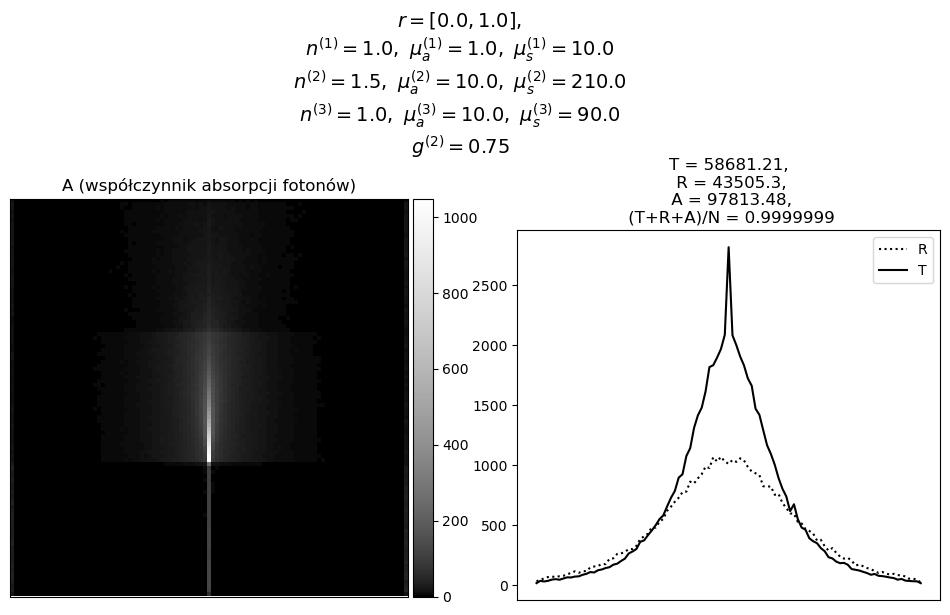

In [12]:
refl_transm = np.loadtxt("reflt_tramsm.dat")
absorption = np.loadtxt("absorption.dat").T
pm = np.loadtxt("pm.dat")

absorption = absorption[:, :]

fig = plt.figure(figsize=(12, 8))
fig.suptitle(
    "$r = [{}, {}],$\n".format(pm[0], pm[1]) +
    "$n^{{(1)}} = {},\\ \\mu_a^{{(1)}} = {},\\ \\mu_s^{{(1)}} = {}$\n".format(pm[2], pm[3], pm[4]) +
    "$n^{{(2)}} = {},\\ \\mu_a^{{(2)}} = {},\\ \\mu_s^{{(2)}} = {}$\n".format(pm[5], pm[6], pm[7]) +
    "$n^{{(3)}} = {},\\ \\mu_a^{{(3)}} = {},\\ \\mu_s^{{(3)}} = {}$\n".format(pm[8], pm[9], pm[10]) +
    "$g^{{(2)}} = {}$".format(pm[11]),
    fontsize=14
)

ax1 = fig.add_subplot(121)
ax1.set_title("A (współczynnik absorpcji fotonów)")
ax1.set_xticks([])
ax1.set_yticks([])
im1 = ax1.imshow(absorption, interpolation='None', cmap=custom_cmap, origin='lower')
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im1, cax=cax, orientation='vertical')

ax2 = fig.add_subplot(122)
ax2.set_title(f"T = {np.sum(refl_transm[1]):.7},\n R = {np.sum(refl_transm[0]):.7},\n A = {np.sum(absorption):.7},\n (T+R+A)/N = {(np.sum(refl_transm)/200000 + np.sum(absorption)/200000):.7}")
ax2.set_xticks([])
box = ax2.get_position()
ax2.set_position([box.x0, box.y0*2.2, box.width, box.height*0.6]) # type: ignore
#ax2.set_yticks([])
#ax2.set_xlabel("x")
im2 = ax2.plot(np.linspace(0, 0.2, len(refl_transm[0])),
            refl_transm[0], ':', color = 'k',  label = "R")
im2 = ax2.plot(np.linspace(0, 0.2, len(refl_transm[1])),
            refl_transm[1], '-', color = 'k' , label = "T")
ax2.legend()
divider = make_axes_locatable(ax2)
#cax = divider.append_axes('right', size='5%', pad=0.05)

plt.savefig("3_d.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()